In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = {
    "Neighborhood": [
        "Downtown", "Downtown", "Suburb", "Suburb", "Riverside",
        "Riverside", "Downtown", "Suburb", "Riverside", "Downtown",
        "Suburb", "Riverside", "Downtown", "Suburb", "Riverside"
    ],
    "Area_sqft": [
        1200, 1500, 1800, 2200, 2500,
        1600, np.nan, 2100, 1900, 1300,
        1750, 2300, 1250, np.nan, 2000
    ],
    "Bedrooms": [
        2, 3, 3, 4, 4,
        3, 2, 4, 3, 2,
        3, 4, 2, 3, 4
    ],
    "Bathrooms": [
        1, 2, 2, 3, 3,
        2, 1, 3, 2, 1,
        2, 3, 1, 2, 3
    ],
    "Age_years": [
        10, 8, 5, 3, 2,
        7, 12, 4, 6, 15,
        5, 2, 20, 8, 3
    ],
    "Price": [
        180000, 230000, 280000, 350000, 400000,
        260000, 190000, 360000, 300000, 200000,
        290000, 380000, 185000, 270000, 1500000
    ]
}

df = pd.DataFrame(data)

df

,Neighborhood,Area_sqft,Bedrooms,Bathrooms,Age_years,Price
0,Downtown,1200.0,2,1,10,180000
1,Downtown,1500.0,3,2,8,230000
2,Suburb,1800.0,3,2,5,280000
3,Suburb,2200.0,4,3,3,350000
4,Riverside,2500.0,4,3,2,400000
5,Riverside,1600.0,3,2,7,260000
6,Downtown,NaN,2,1,12,190000
7,Suburb,2100.0,4,3,4,360000
8,Riverside,1900.0,3,2,6,300000
9,Downtown,1300.0,2,1,15,200000


In [12]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

df.head()

Dataset shape: (15, 6)

Missing values:
Neighborhood    0
Area_sqft       2
Bedrooms        0
Bathrooms       0
Age_years       0
Price           0
dtype: int64

Data types:
Neighborhood        str
Area_sqft       float64
Bedrooms          int64
Bathrooms         int64
Age_years         int64
Price             int64
dtype: object


,Neighborhood,Area_sqft,Bedrooms,Bathrooms,Age_years,Price
0,Downtown,1200.0,2,1,10,180000
1,Downtown,1500.0,3,2,8,230000
2,Suburb,1800.0,3,2,5,280000
3,Suburb,2200.0,4,3,3,350000
4,Riverside,2500.0,4,3,2,400000


In [13]:
# Fill missing numerical values with the median
df["Area_sqft"] = df["Area_sqft"].fillna(df["Area_sqft"].median())

# Check again
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Neighborhood    0
Area_sqft       0
Bedrooms        0
Bathrooms       0
Age_years       0
Price           0
dtype: int64


In [14]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df[
    (df["Price"] < lower_bound) |
    (df["Price"] > upper_bound)
]

print("\nOutliers:")
print(outliers)

Lower bound: 5000.0
Upper bound: 565000.0

Outliers:
   Neighborhood  Area_sqft  Bedrooms  Bathrooms  Age_years    Price
14    Riverside     2000.0         4          3          3  1500000


In [15]:
df_clean = df[
    (df["Price"] >= lower_bound) &
    (df["Price"] <= upper_bound)
].copy()

print("Original rows:", len(df))
print("Rows after outlier removal:", len(df_clean))

Original rows: 15
Rows after outlier removal: 14


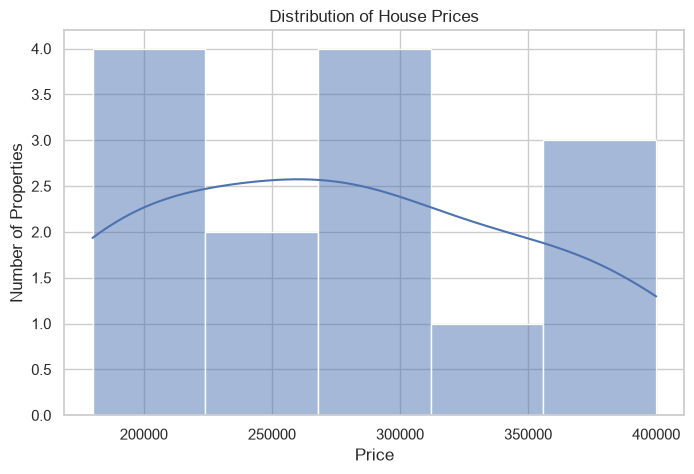

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(df_clean["Price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Properties")
plt.show()

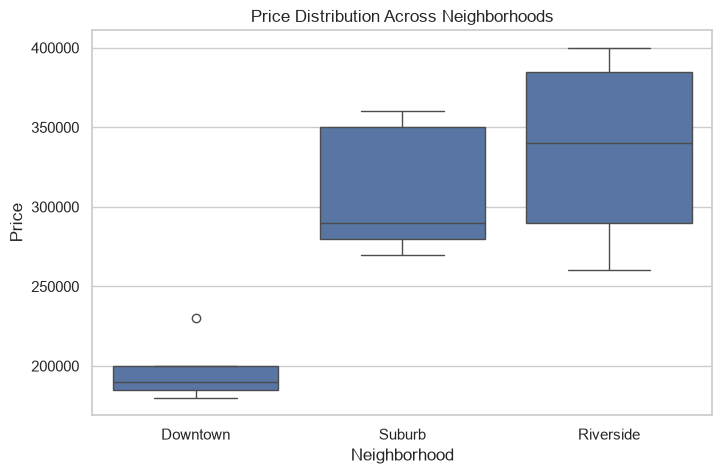

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Neighborhood",
    y="Price"
)

plt.title("Price Distribution Across Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Price")
plt.show()

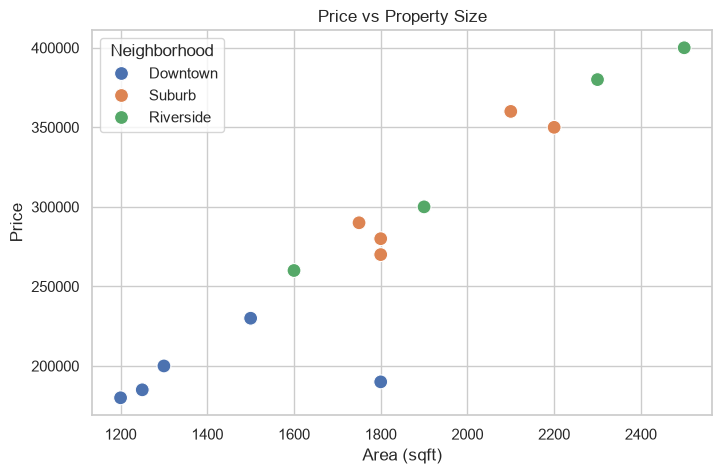

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Area_sqft",
    y="Price",
    hue="Neighborhood",
    s=100
)

plt.title("Price vs Property Size")
plt.xlabel("Area (sqft)")
plt.ylabel("Price")
plt.show()

Neighborhood
Downtown     197000.0
Suburb       310000.0
Riverside    335000.0
Name: Price, dtype: float64


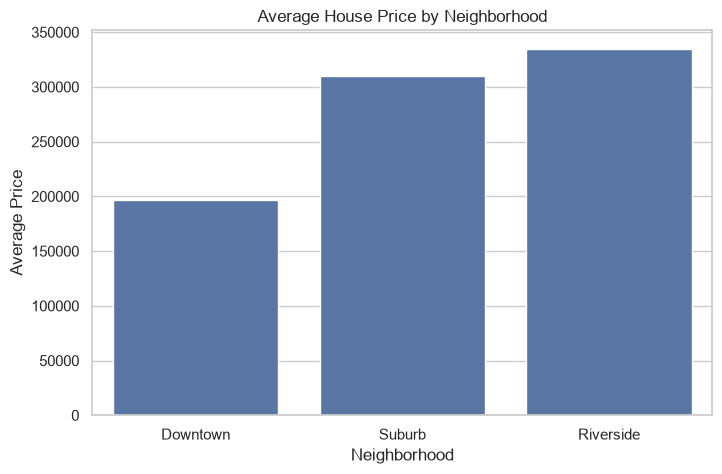

In [19]:
avg_price = df_clean.groupby("Neighborhood")["Price"].mean().sort_values()

print(avg_price)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_price.index,
    y=avg_price.values
)

plt.title("Average House Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price")
plt.show()